# biocal interactive tutorial

# 1 Getting started

## 1.1 Installing the biocal package

To run this toturial you must have installed the `biocal` package in your python environment. If you have not done so already, you can follow the instructions at the [github repository](https://www.github.com/bryanlougheed/biocal) to install the package to your python environment using the Linux terminal, Windows powershell or equivalent.

## 1.2 Importing biocal function 

After installation, we can import the `biocal` function into our python session. We will also import `matplotlib` so that we can plot some things.

In [5]:
from biocal import biocal
import matplotlib.pyplot as plt

# 2 Calibrate a date with SAR an BD priors

Below, we can use the `biocal()` function to calibrate a 14C determination of 17500 +/- 100 14C yrs (`Adet` and `sigdet`). We will use the calibration curve (`calcurve`) Marine20 and apply a constant reservoir age prior (`res`) of 650 +/- 40 14C yrs. We will apply a sediment accumulation rate prior(`sar`) of 10 cm/kyr and a bioturbation depth prior (`bd`) of 10 cm. We will assume that 10% of the foraminifera population is broken and thus not picked for the sample, so we will set `brok` to 0.1. We assume constant temporal abundance of the foraminifera species, so we set `abu` to empty. Output will be specified in `Cal BP` (as opposed to `BCE/CE`). Subsequently, we can plot the resulting credible calibrated age distribution (`calprob`) from `biocal`.

If you need documention for the function then type `?biocal` into the python command line.


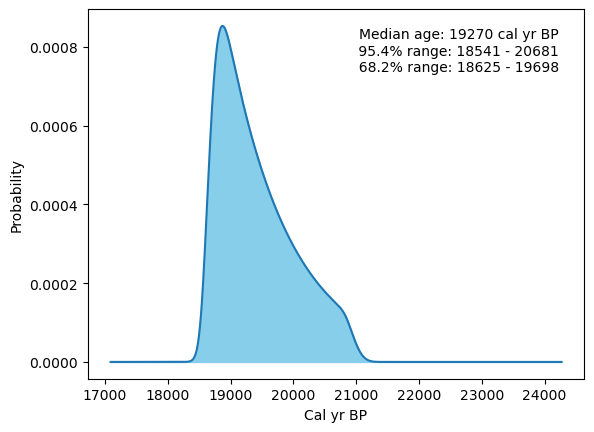

In [8]:
Adet = 17500
sigdet = 100
calcurve = 'Marine20'
yeartype = 'Cal BP'
sar = 10
bd = 10
brok = 0.1
abu = []
res = [650, 40]

p95_4, p95, p68_2, calprob, medage = biocal(Adet, sigdet, calcurve, yeartype, sar, bd, brok, abu, res)

# plot output 
plt.fill_between(calprob[:, 0], calprob[:, 1], color='skyblue')
plt.plot(calprob[:, 0], calprob[:, 1])
plt.xlabel('Cal yr BP')
plt.ylabel('Probability')

plt.text(0.95, 0.95,
    f'Median age: {round(medage)} cal yr BP\n 95.4% range: {round(p95_4[0,1])} - {round(p95_4[0,0])}\n  68.2% range: {round(p68_2[0,1])} - {round(p68_2[0,0])}',
    transform=plt.gca().transAxes,
    ha='right',
    va='top'
)

plt.show()